In [1]:
from google.colab import files

uploaded = files.upload()


Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("retail_sales_dataset.csv")

In [6]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [9]:
df.shape

(1000, 9)

In [10]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [11]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
# Data Cleaning

In [13]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [18]:
df['Month'] = df['Date'].dt.month

df['Year'] = df['Date'].dt.year

df['Day_Name'] = df['Date'].dt.day_name()

df['Quarter'] = df['Date'].dt.quarter

In [19]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Day_Name,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,2023,Friday,4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,2023,Monday,1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,2023,Friday,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,2023,Sunday,2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,2023,Saturday,2


In [ ]:
# Exploratory Data Analysis

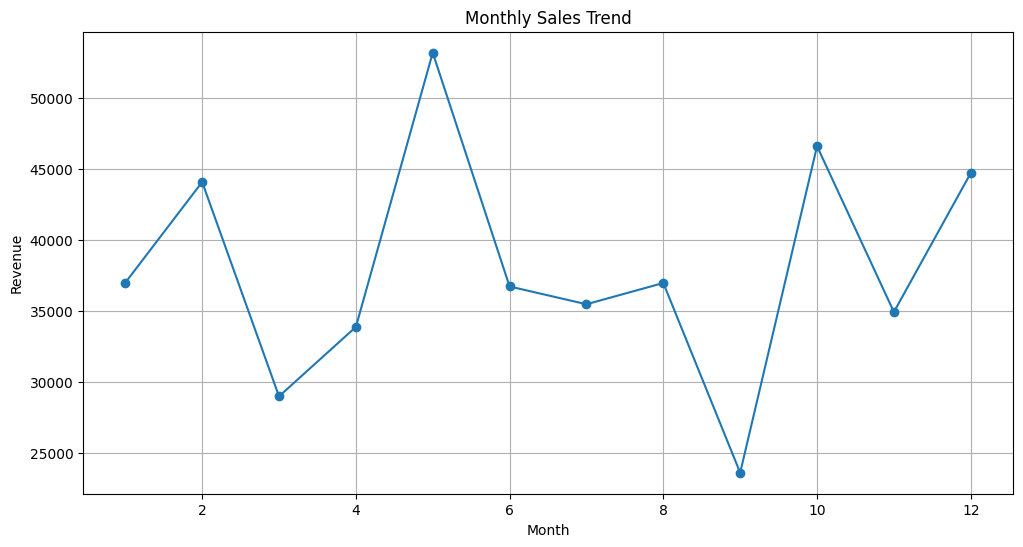

In [20]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.grid()

plt.show()

In [21]:
plt.savefig("monthly_sales_trend.png")

<Figure size 640x480 with 0 Axes>

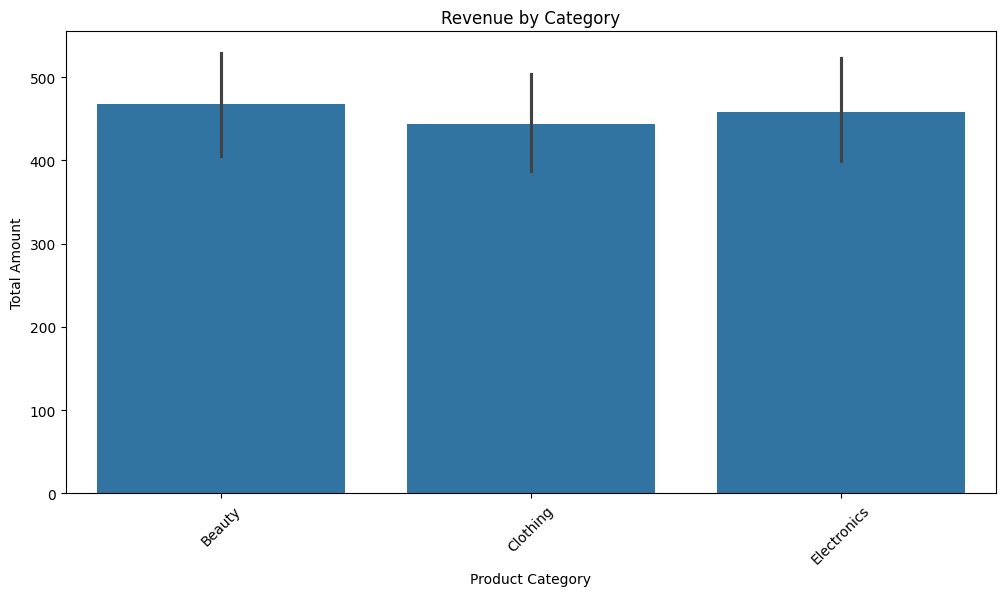

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Product Category',
    y='Total Amount',
    data=df
)

plt.xticks(rotation=45)

plt.title("Revenue by Category")

plt.show()

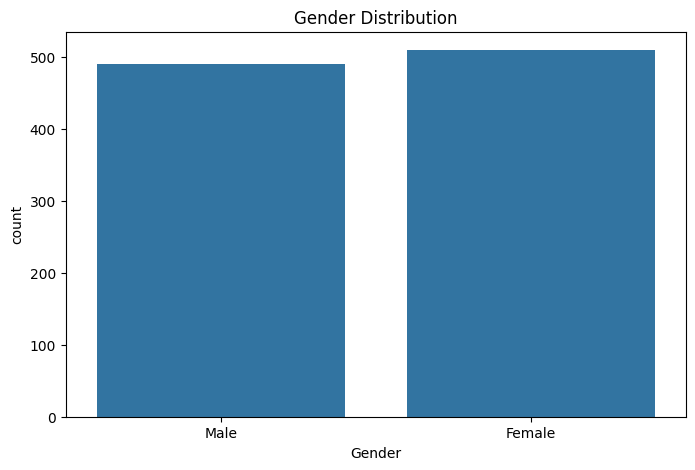

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Gender',
    data=df
)

plt.title("Gender Distribution")

plt.show()

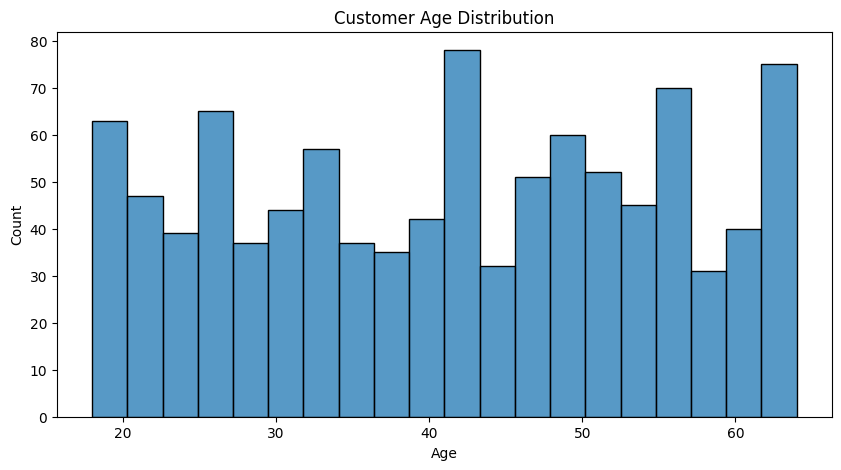

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Age'],
    bins=20
)

plt.title("Customer Age Distribution")

plt.show()

In [ ]:
# Customer Segmentation

In [26]:
customer_spend = df.groupby(
    'Customer ID'
)['Total Amount'].sum().reset_index()

In [27]:
customer_spend.head()

,Customer ID,Total Amount
0,CUST001,150
1,CUST002,1000
2,CUST003,30
3,CUST004,500
4,CUST005,100


In [28]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    customer_spend[['Total Amount']]
)

In [29]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer_spend['Cluster'] = kmeans.fit_predict(
    scaled_data
)

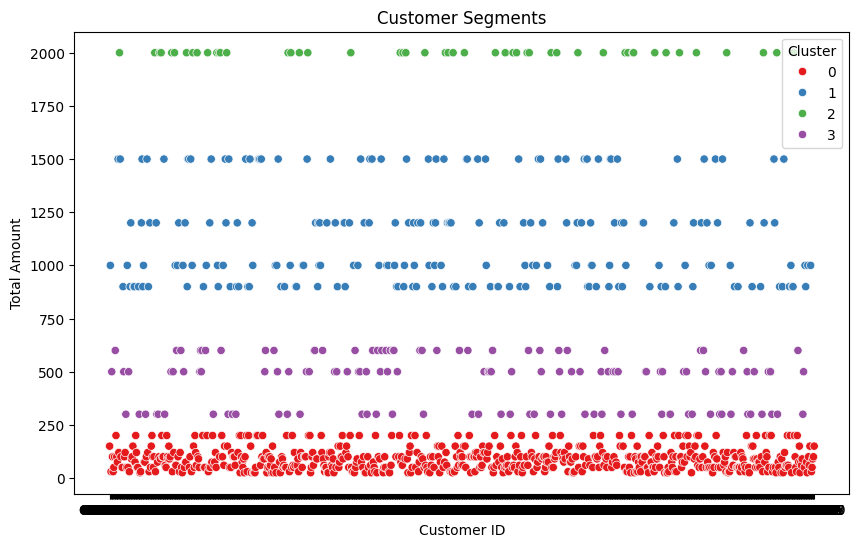

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Customer ID',
    y='Total Amount',
    hue='Cluster',
    data=customer_spend,
    palette='Set1'
)

plt.title("Customer Segments")

plt.show()

In [ ]:
# RFM Analysis

In [31]:
snapshot_date = df['Date'].max()

In [32]:
rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Amount': 'sum'
})

In [33]:
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

In [34]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
CUST001,38,1,150
CUST002,308,1,1000
CUST003,353,1,30
CUST004,225,1,500
CUST005,240,1,100


In [ ]:
# Sales Forecasting

In [35]:
daily_sales = df.groupby(
    'Date'
)['Total Amount'].sum()

In [36]:
daily_sales.head()

,Total Amount
Date,
2023-01-01,3600
2023-01-02,1765
2023-01-03,600
2023-01-04,1240
2023-01-05,1100


<Axes: xlabel='Date'>

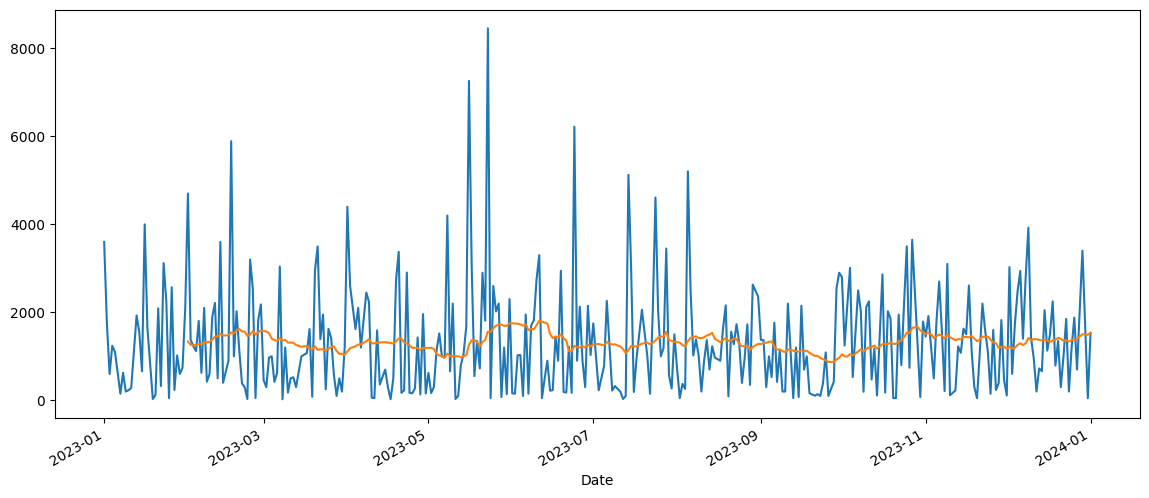

In [37]:
daily_sales.plot(
    figsize=(14,6)
)

daily_sales.rolling(
    window=30
).mean().plot()

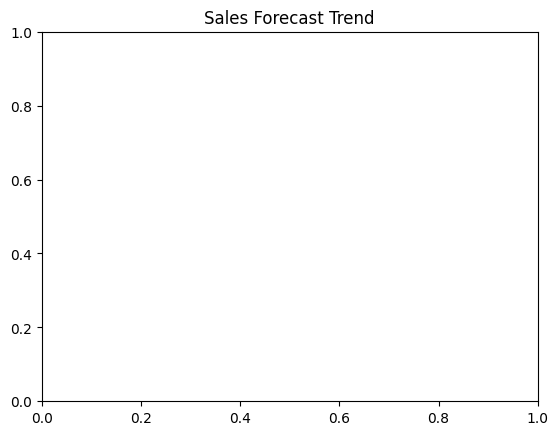

In [38]:
plt.title(
    "Sales Forecast Trend"
)

plt.show()

In [ ]:
# Business Recommendations

1. Electronics category generates highest revenue.

2. Female customers contribute more purchases.

3. Cluster 2 customers are premium customers.

4. Q4 generates maximum revenue.

5. Future sales show upward trend.

In [39]:
plt.savefig(
    "chart_name.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>